# Step 2: Multi-source Dijkstra — Voronoi Visualization

Build a cost map from the background-corrected image, then run multi-source Dijkstra
with all annotation component pixels as simultaneous sources (cost = 0).

Each pixel records:
- **component_id**: which annotation component "owns" it
- **cost**: accumulated traversal cost to reach it

**Goal**: Visualize the Voronoi partition and verify that region boundaries
naturally fall in dark areas between fibers.

In [1]:
import numpy as np
import cv2
import skimage as ski
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from skimage.measure import regionprops
from scipy import ndimage
import heapq

from neural_reconstruction.core.preprocessing import dilate_epidermis_vertically
from neural_reconstruction.dataset import DatasetLoader

BASE_PATH = Path('/home/pony/projects/ienf_q/data_0331')
IMAGE_ID  = 'S1585-2_b'

## 1. Preprocessing (following preprocess.ipynb)

In [2]:
image      = cv2.imread(str(BASE_PATH / IMAGE_ID / 'image.png'),      cv2.IMREAD_COLOR_RGB)[:, :, 1]
mask       = cv2.imread(str(BASE_PATH / IMAGE_ID / 'mask.png'),       cv2.IMREAD_GRAYSCALE)
annotation = cv2.imread(str(BASE_PATH / IMAGE_ID / 'weka.png'),       cv2.IMREAD_GRAYSCALE)
label      = cv2.imread(str(BASE_PATH / IMAGE_ID / 'label.png'),      cv2.IMREAD_GRAYSCALE)
# ROI mask
roi_mask = dilate_epidermis_vertically(mask, offset_px=50)

# Background removal
kernel     = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (51, 51))
background = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
image      = cv2.subtract(image, background)

roi_image      = cv2.bitwise_and(image,      image,      mask=roi_mask)
roi_annotation = cv2.bitwise_and(annotation, annotation, mask=roi_mask)
roi_label      = cv2.bitwise_and(label,      label,      mask=roi_mask)

# CLAHE + Sato vesselness
clahe     = cv2.createCLAHE(clipLimit=20.0, tileGridSize=(16, 16))
roi_image = clahe.apply(roi_image)
roi_image = ski.filters.sato(roi_image, sigmas=range(3, 8), black_ridges=False)
roi_image = (roi_image - roi_image.min()) / (roi_image.max() - roi_image.min()) * 255
roi_image = roi_image.astype(np.uint8)


print(f'Image shape: {roi_image.shape}')
print(f'Annotation pixels: {(roi_annotation > 127).sum()}')

Image shape: (1946, 5632)
Annotation pixels: 13950


## 2. Cost Map

Bright pixels (nerve tissue) = low traversal cost.  
Dark pixels (background) = high cost.

`cost = 1 - normalized_intensity`

In [3]:
# Normalize to [0, 1] and invert: bright -> low cost
intensity_norm = roi_image.astype(np.float32) / 255.0
cost_map = 1.0 - intensity_norm  # float32, range [0, 1]
cost_map = np.exp(cost_map) - 1.0  # Exponential to amplify differences

# fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# axes[0].imshow(roi_image, cmap='gray')
# axes[0].set_title('Enhanced Image (Sato)')
# axes[0].axis('off')
# im = axes[1].imshow(cost_map, cmap='hot')
# axes[1].set_title('Cost Map (bright = expensive to traverse)')
# axes[1].axis('off')
# plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
# plt.tight_layout()
# plt.show()

## 3. Multi-source Dijkstra

All annotation component pixels start at cost 0.  
Each pixel tracks `(component_id, accumulated_cost)`.

In [4]:
def get_components(binary_img, min_area=0):
    labeled = ski.measure.label(binary_img, connectivity=1)
    for p in regionprops(labeled):
        if p.area < min_area:
            labeled[labeled == p.label] = 0
    labeled, _ = ndimage.label(labeled > 0)
    return labeled


def compute_per_component_thresholds(cost_map, annot_labeled, k=1.5):
    thresholds = {}
    n = annot_labeled.max()
    for cid in range(1, n + 1):
        seed_costs = cost_map[annot_labeled == cid]
        mu  = float(seed_costs.mean())
        sig = float(seed_costs.std())
        thresholds[cid] = mu + k * sig
    return thresholds


def multi_source_dijkstra(cost_map, annot_labeled, connectivity=8, thresholds=None):
    """
    Returns: owner_map, dist_map, prev_y, prev_x
      prev_y/prev_x: predecessor coordinates for backtracking (-1 at annotation seeds)
    """
    H, W = cost_map.shape

    if connectivity == 4:
        neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    else:
        neighbors = [(-1, -1), (-1, 0), (-1, 1),
                     ( 0, -1),           ( 0, 1),
                     ( 1, -1), ( 1, 0),  ( 1, 1)]

    dist_map  = np.full((H, W), np.inf, dtype=np.float32)
    owner_map = np.zeros((H, W), dtype=np.int32)
    prev_y    = np.full((H, W), -1, dtype=np.int32)
    prev_x    = np.full((H, W), -1, dtype=np.int32)

    heap = []
    ys, xs = np.where(annot_labeled > 0)
    for y, x in zip(ys, xs):
        cid = int(annot_labeled[y, x])
        dist_map[y, x]  = 0.0
        owner_map[y, x] = cid
        heapq.heappush(heap, (0.0, y, x, cid))

    while heap:
        d, y, x, cid = heapq.heappop(heap)
        if d > dist_map[y, x]:
            continue
        if thresholds is not None and d > thresholds[cid]:
            continue

        for dy, dx in neighbors:
            ny, nx = y + dy, x + dx
            if not (0 <= ny < H and 0 <= nx < W):
                continue
            new_dist = d + float(cost_map[ny, nx])
            if thresholds is not None and new_dist > thresholds[cid]:
                continue
            if new_dist < dist_map[ny, nx]:
                dist_map[ny, nx]  = new_dist
                owner_map[ny, nx] = cid
                prev_y[ny, nx]    = y
                prev_x[ny, nx]    = x
                heapq.heappush(heap, (new_dist, ny, nx, cid))

    return owner_map, dist_map, prev_y, prev_x

In [5]:
K = 20  # stopping threshold multiplier: mean + K * std

annotation_bin = (roi_annotation > 127).astype(np.uint8)
annot_labeled  = get_components(annotation_bin)
n_components   = annot_labeled.max()
print(f'Annotation components: {n_components}')

print('Running multi-source Dijkstra with adaptive stopping...')
owner_map, dist_map, prev_y, prev_x = multi_source_dijkstra(
    cost_map, annot_labeled, connectivity=8
)
print(f'  Pixels reached : {(owner_map > 0).sum():,}')
print(f'  Coverage       : {(owner_map > 0).mean()*100:.1f}% of image')

Annotation components: 861
Running multi-source Dijkstra with adaptive stopping...
  Pixels reached : 10,959,872
  Coverage       : 100.0% of image


## 4. Voronoi Visualization

Color each pixel by which annotation component owns it.  
Check: do the region boundaries fall in dark areas (background) between fibers?

In [6]:
def make_voronoi_rgb(owner_map, roi_mask=None):
    """Color each owned pixel by a random color per component."""
    n = owner_map.max()
    rng = np.random.default_rng(42)
    colors = rng.integers(60, 255, size=(n + 1, 3), dtype=np.uint8)
    colors[0] = 0  # background = black

    rgb = colors[owner_map]  # (H, W, 3)

    if roi_mask is not None:
        rgb[roi_mask == 0] = 0

    return rgb


def boundary_overlay(owner_map, image_gray, roi_mask=None, alpha=0.5):
    """Overlay Voronoi boundaries on the image."""
    # Detect boundaries: pixel differs from any neighbor
    from scipy.ndimage import generic_filter

    def is_boundary(patch):
        center = patch[4]  # 3x3 patch, center = index 4
        return 1.0 if center > 0 and np.any(patch != center) else 0.0

    boundary = generic_filter(owner_map.astype(float), is_boundary, size=3)
    boundary = boundary > 0

    img_rgb = np.stack([image_gray] * 3, axis=-1).astype(np.uint8)
    img_rgb[boundary] = [255, 0, 0]  # red boundaries

    if roi_mask is not None:
        img_rgb[roi_mask == 0] = 0

    return img_rgb, boundary


voronoi_rgb = make_voronoi_rgb(owner_map, roi_mask)
boundary_rgb, boundary_mask = boundary_overlay(owner_map, roi_image, roi_mask)


fig_size_x = 128
fig_size_y = int(roi_image.shape[0] / roi_image.shape[1] * fig_size_x)

fig, axes = plt.subplots(1, 1, figsize=(fig_size_x, fig_size_y))

# axes[0].imshow(roi_image, cmap='gray')
# axes[0].set_title('Enhanced Image')
# axes[0].axis('off')

axes.imshow(voronoi_rgb)
axes.set_title(f'Voronoi Partition ({n_components} components)')
axes.axis('off')

# axes[2].imshow(boundary_rgb)
# axes[2].set_title('Voronoi Boundaries on Image\n(red = partition boundary)')
# axes[2].axis('off')

plt.suptitle(f'Sample: {IMAGE_ID}', fontsize=13)
plt.tight_layout()
plt.savefig(f'{IMAGE_ID}_voronoi.png')
plt.close(fig)

In [7]:
# # Zoomed-in view of a region of interest
# # Adjust the crop window to inspect specific areas
# H, W = roi_image.shape
# cy, cx = H // 2, W // 2  # center of crop (adjust as needed)
# half   = 300

# y0, y1 = max(0, cy - half), min(H, cy + half)
# x0, x1 = max(0, cx - half), min(W, cx + half)

# fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# axes[0].imshow(roi_image[y0:y1, x0:x1], cmap='gray')
# axes[0].set_title('Enhanced Image (zoomed)')
# axes[0].axis('off')

# axes[1].imshow(voronoi_rgb[y0:y1, x0:x1])
# axes[1].set_title('Voronoi Partition (zoomed)')
# axes[1].axis('off')

# axes[2].imshow(boundary_rgb[y0:y1, x0:x1])
# axes[2].set_title('Boundaries on Image (zoomed)')
# axes[2].axis('off')

# plt.tight_layout()
# plt.show()

## 5. Boundary Quality Check

Quantify: what fraction of boundary pixels fall in dark regions (low intensity)?
If boundaries tend to land in dark areas, the cost map is guiding expansion correctly.

Intensity statistics:
  All owned pixels  — mean: 37.2, median: 24.0
  Boundary pixels   — mean: 35.7, median: 21.0

  Fraction of boundary pixels in bottom-30% intensity: 31.6%
  (If >> 30%, boundaries prefer dark areas — cost map is working)


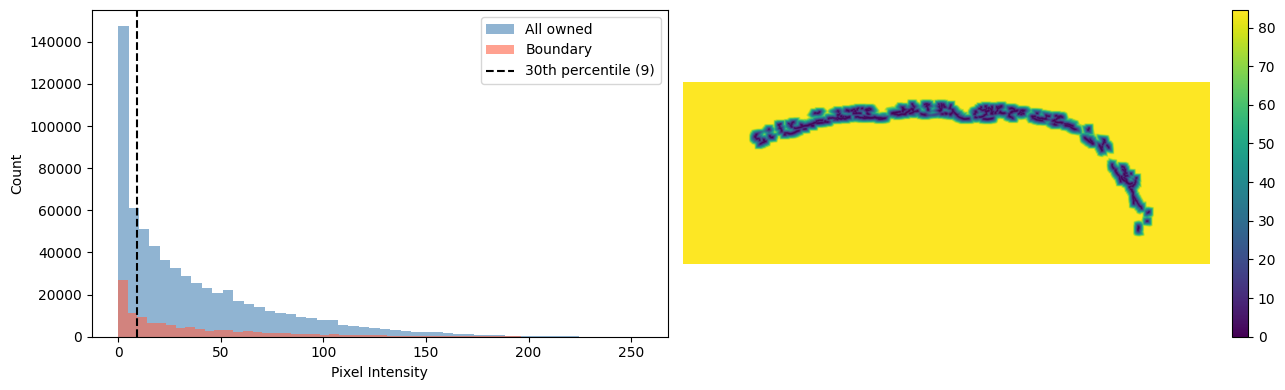

In [8]:
# Sample intensity at boundary pixels vs all owned pixels
all_owned = (owner_map > 0) & (roi_mask > 0)
boundary_in_roi = boundary_mask & (roi_mask > 0)

intensity_owned    = roi_image[all_owned].astype(float)
intensity_boundary = roi_image[boundary_in_roi].astype(float)

print('Intensity statistics:')
print(f'  All owned pixels  — mean: {intensity_owned.mean():.1f}, median: {np.median(intensity_owned):.1f}')
print(f'  Boundary pixels   — mean: {intensity_boundary.mean():.1f}, median: {np.median(intensity_boundary):.1f}')
print()
thresh = np.percentile(intensity_owned, 30)  # bottom 30% = "dark"
pct_dark = (intensity_boundary < thresh).mean() * 100
print(f'  Fraction of boundary pixels in bottom-30% intensity: {pct_dark:.1f}%')
print(f'  (If >> 30%, boundaries prefer dark areas — cost map is working)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(intensity_owned,    bins=50, alpha=0.6, label='All owned', color='steelblue')
axes[0].hist(intensity_boundary, bins=50, alpha=0.6, label='Boundary',  color='tomato')
axes[0].axvline(thresh, color='black', linestyle='--', label=f'30th percentile ({thresh:.0f})')
axes[0].set_xlabel('Pixel Intensity')
axes[0].set_ylabel('Count')
axes[0].legend()

im = axes[1].imshow(dist_map, cmap='viridis',
                    vmax=np.percentile(dist_map[all_owned], 95))
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 6. Meeting Points Between Components

Scan the `owner_map`: whenever pixel A and neighbor pixel B belong to different components,
that's a **meeting point**. The meeting cost = `dist[A] + dist[B]`.

For each component pair, keep only the **minimum** meeting cost (the cheapest connection).

In [10]:
def _backtrack(y, x, prev_y, prev_x):
    """Trace Dijkstra path from pixel (y,x) back to its annotation seed."""
    path = []
    while y >= 0 and x >= 0:
        path.append((int(y), int(x)))
        py, px = int(prev_y[y, x]), int(prev_x[y, x])
        if py < 0:
            break
        y, x = py, px
    return path


def find_meeting_points(owner_map, dist_map, prev_y=None, prev_x=None):
    """
    Find the minimum-cost meeting point for every adjacent component pair.

    If prev_y/prev_x are provided, backtrack the full path:
      seed_A -> ... -> meeting_A -> meeting_B -> ... -> seed_B
    and store it in connections[(A,B)]['path'].

    Returns:
        connections: dict {(A, B): {'cost', 'y', 'x', 'y_b', 'x_b', ['path']}}
    """
    shifts = [(0, 1), (1, 0), (1, 1), (1, -1)]
    connections = {}

    for dy, dx in shifts:
        if dy > 0:
            oa = owner_map[:-dy, :];  ob = owner_map[dy:, :]
            da = dist_map[:-dy, :];   db = dist_map[dy:, :]
            ys_offset = 0
        else:
            oa = ob = owner_map;  da = db = dist_map;  ys_offset = 0

        if dx > 0:
            oa = oa[:, :-dx];  ob = ob[:, dx:]
            da = da[:, :-dx];  db = db[:, dx:]
            xs_offset = 0
        elif dx < 0:
            oa = oa[:, -dx:];  ob = ob[:, :dx]
            da = da[:, -dx:];  db = db[:, :dx]
            xs_offset = -dx
        else:
            xs_offset = 0

        meet = (oa > 0) & (ob > 0) & (oa != ob)
        ys_local, xs_local = np.where(meet)
        if len(ys_local) == 0:
            continue

        a_ids    = oa[ys_local, xs_local].astype(int)
        b_ids    = ob[ys_local, xs_local].astype(int)
        costs    = da[ys_local, xs_local] + db[ys_local, xs_local]
        global_y = ys_local + ys_offset
        global_x = xs_local + xs_offset

        for a, b, cost, gy, gx in zip(a_ids, b_ids, costs, global_y, global_x):
            key = (min(a, b), max(a, b))
            if key not in connections or cost < connections[key]['cost']:
                connections[key] = {
                    'cost': float(cost),
                    'y':   int(gy),
                    'x':   int(gx),
                    'y_b': int(gy + dy),
                    'x_b': int(gx + dx),
                }

    if prev_y is not None and prev_x is not None:
        for info in connections.values():
            path_a = _backtrack(info['y'],   info['x'],   prev_y, prev_x)
            path_b = _backtrack(info['y_b'], info['x_b'], prev_y, prev_x)
            info['path'] = list(reversed(path_a)) + path_b

    return connections


connections = find_meeting_points(owner_map, dist_map, prev_y, prev_x)
costs_all   = np.array([v['cost'] for v in connections.values()])
print(f'Component pairs with a meeting point: {len(connections)}')
print(f'Meeting cost — mean: {costs_all.mean():.2f}, median: {np.median(costs_all):.2f}, '
      f'min: {costs_all.min():.2f}, max: {costs_all.max():.2f}')

# connections_full = find_meeting_points(owner_full, dist_full)
# print(f'Without stopping — component pairs: {len(connections_full)}')
# print(f'With stopping    — component pairs: {len(connections)}')
# print(f'Pairs eliminated by stopping      : {len(connections_full) - len(connections)}')

Component pairs with a meeting point: 2402
Meeting cost — mean: 107.00, median: 12.52, min: 0.00, max: 4944.93


## 7. GT Validation: Same-fiber vs Cross-fiber Meeting Costs

Map each annotation component to its GT fiber (majority overlap),
then classify every component pair as **same-fiber** or **cross-fiber**.

If the cost map is guiding expansion correctly, same-fiber pairs should have clearly lower meeting costs.

In [11]:
# Load GT label and find fibers
label_img  = cv2.imread(str(BASE_PATH / IMAGE_ID / 'label.png'), cv2.IMREAD_GRAYSCALE)
gt_labeled, n_gt = ndimage.label(label_img > 127)
print(f'GT fibers: {n_gt}')

# Map each annotation component -> dominant GT fiber (majority vote)
annot_to_gt = {}  # annot_id -> gt_id (0 = no GT overlap)

for a_id in range(1, n_components + 1):
    a_mask   = annot_labeled == a_id
    gt_under = gt_labeled[a_mask]
    gt_under = gt_under[gt_under > 0]

    if len(gt_under) == 0:
        annot_to_gt[a_id] = 0
    else:
        unique, counts = np.unique(gt_under, return_counts=True)
        annot_to_gt[a_id] = int(unique[counts.argmax()])

n_with_gt = sum(v > 0 for v in annot_to_gt.values())
print(f'Annotation components with GT mapping: {n_with_gt}/{n_components}')

GT fibers: 99
Annotation components with GT mapping: 856/861


In [12]:
# Classify connections: same-fiber / cross-fiber / unknown
same_fiber_costs  = []
cross_fiber_costs = []
unknown_costs     = []

for (a, b), info in connections.items():
    gt_a = annot_to_gt.get(a, 0)
    gt_b = annot_to_gt.get(b, 0)

    if gt_a == 0 or gt_b == 0:
        unknown_costs.append(info['cost'])
    elif gt_a == gt_b:
        same_fiber_costs.append(info['cost'])
    else:
        cross_fiber_costs.append(info['cost'])

same  = np.array(same_fiber_costs)
cross = np.array(cross_fiber_costs)

print('Meeting cost by connection type:')
print(f'  Same-fiber  (n={len(same):4d}): '
      f'mean={same.mean():.2f},  median={np.median(same):.2f},  p90={np.percentile(same, 90):.2f}')
print(f'  Cross-fiber (n={len(cross):4d}): '
      f'mean={cross.mean():.2f},  median={np.median(cross):.2f},  p10={np.percentile(cross, 10):.2f}')
print(f'  Unknown     (n={len(unknown_costs):4d})')
print()
# Key separability metric: how many same-fiber pairs are cheaper than the cross-fiber median?
cross_median = np.median(cross)
separability = (same < cross_median).mean() * 100
print(f'  Same-fiber costs below cross-fiber median: {separability:.1f}%')
print(f'  (Ideal >> 50%: same-fiber connections are consistently cheaper)')

Meeting cost by connection type:
  Same-fiber  (n=1520): mean=14.28,  median=3.55,  p90=35.74
  Cross-fiber (n= 849): mean=265.90,  median=55.25,  p10=14.83
  Unknown     (n=  33)

  Same-fiber costs below cross-fiber median: 93.7%
  (Ideal >> 50%: same-fiber connections are consistently cheaper)


In [15]:
# Classify connections_full (no stopping) by same/cross fiber
# full_same  = set()
# full_cross = set()

# for (a, b) in connections_full:
#     gt_a = annot_to_gt.get(a, 0)
#     gt_b = annot_to_gt.get(b, 0)
#     if gt_a == 0 or gt_b == 0:
#         continue
#     if gt_a == gt_b:
#         full_same.add((a, b))
#     else:
#         full_cross.add((a, b))

# Which of those survive the stopping condition?
stopped_same  = set()
stopped_cross = set()

for (a, b) in connections:
    gt_a = annot_to_gt.get(a, 0)
    gt_b = annot_to_gt.get(b, 0)
    if gt_a == 0 or gt_b == 0:
        continue
    if gt_a == gt_b:
        stopped_same.add((a, b))
    else:
        stopped_cross.add((a, b))

# recall    = len(stopped_same)  / max(len(full_same),  1)
# # precision_gain = (len(full_cross) - len(stopped_cross)) / max(len(full_cross), 1)

# print('Recall / Precision trade-off (k={:.1f}):'.format(K))
# print()
# print(f'  Same-fiber pairs (no stop)  : {len(full_same):4d}')
# print(f'  Same-fiber pairs (stopped)  : {len(stopped_same):4d}')
# print(f'  Lost connections            : {len(full_same) - len(stopped_same):4d}')
# print(f'  Recall                      : {recall*100:.1f}%')
# print()
# print(f'  Cross-fiber pairs (no stop) : {len(full_cross):4d}')
# print(f'  Cross-fiber pairs (stopped) : {len(stopped_cross):4d}')
# print(f'  Eliminated errors           : {len(full_cross) - len(stopped_cross):4d}')
# print(f'  Error elimination rate      : {precision_gain*100:.1f}%')
# print()
# print(f'  -> k={K}: kept {recall*100:.1f}% of correct connections, ')
# print(f'           eliminated {precision_gain*100:.1f}% of wrong connections.')

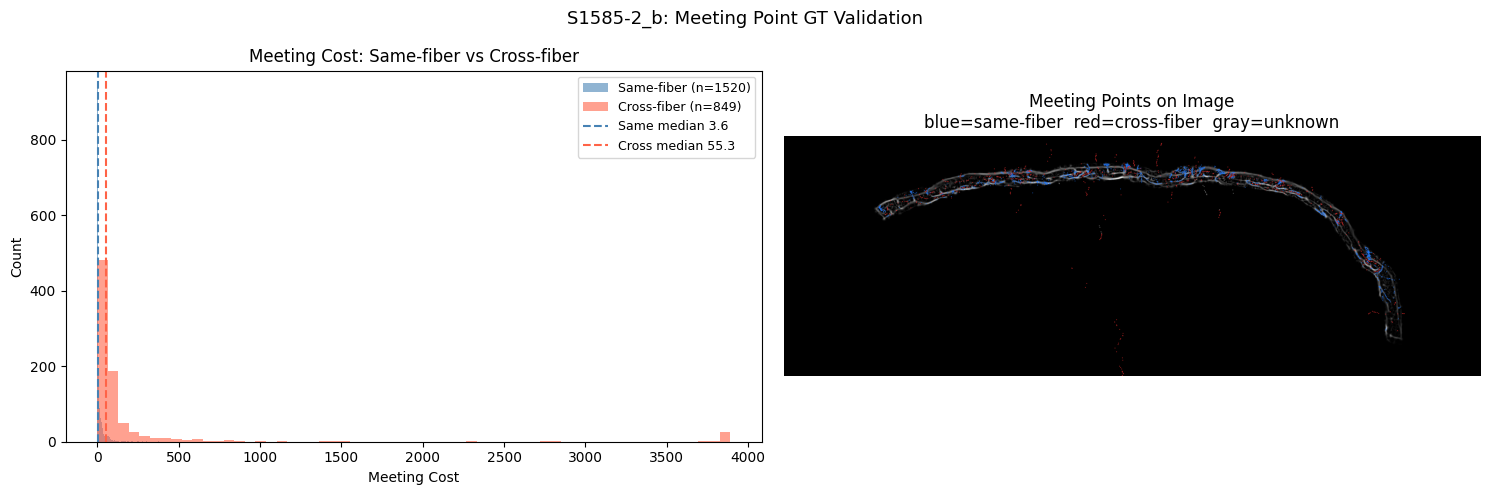

In [16]:
clip_pct = 99
clip_val = np.percentile(np.concatenate([same, cross]), clip_pct)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Cost distribution
axes[0].hist(np.clip(same,  0, clip_val), bins=60, alpha=0.6,
             label=f'Same-fiber (n={len(same)})',  color='steelblue')
axes[0].hist(np.clip(cross, 0, clip_val), bins=60, alpha=0.6,
             label=f'Cross-fiber (n={len(cross)})', color='tomato')
axes[0].axvline(np.median(same),  color='steelblue', linestyle='--', linewidth=1.5,
                label=f'Same median {np.median(same):.1f}')
axes[0].axvline(np.median(cross), color='tomato',    linestyle='--', linewidth=1.5,
                label=f'Cross median {np.median(cross):.1f}')
axes[0].set_xlabel('Meeting Cost')
axes[0].set_ylabel('Count')
axes[0].set_title('Meeting Cost: Same-fiber vs Cross-fiber')
axes[0].legend(fontsize=9)

# Spatial: meeting points colored by type
viz = np.stack([roi_image] * 3, axis=-1).astype(np.uint8)
for (a, b), info in connections.items():
    gt_a = annot_to_gt.get(a, 0)
    gt_b = annot_to_gt.get(b, 0)
    y, x = info['y'], info['x']
    if gt_a > 0 and gt_b > 0 and gt_a == gt_b:
        color = (30, 120, 255)   # blue = same-fiber
    elif gt_a > 0 and gt_b > 0:
        color = (255, 50, 50)    # red = cross-fiber
    else:
        color = (160, 160, 160)  # gray = unknown
    cv2.circle(viz, (x, y), radius=3, color=color, thickness=-1)

axes[1].imshow(viz)
axes[1].set_title('Meeting Points on Image\nblue=same-fiber  red=cross-fiber  gray=unknown')
axes[1].axis('off')

plt.suptitle(f'{IMAGE_ID}: Meeting Point GT Validation', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Component Graph → Edge Pruning → MST

Each annotation component is a **super node**.
Meeting points provide candidate edges (weight = minimum meeting cost).

Steps:
1. Build complete component graph from `connections`
2. Prune edges where cost > mean + 1.5 × std
3. Run MST (Kruskal) on the pruned graph

In [17]:
import networkx as nx

PRUNE_K = 0.5  # remove edges with cost > mean + PRUNE_K * std

# ── 1. Build component graph ──────────────────────────────────────────────
G = nx.Graph()
G.add_nodes_from(range(1, n_components + 1))

for (a, b), info in connections.items():
    if G.has_edge(a, b):
        # If multiple meeting points exist between the same pair, keep the cheapest
        if info['cost'] < G[a][b]['weight']:
            G[a][b].update(weight=info['cost'], y=info['y'], x=info['x'], path=info.get('path', []))
    else:
        G.add_edge(a, b, weight=info['cost'], y=info['y'], x=info['x'], path=info.get('path', []))

edge_costs = np.array([d['weight'] for _, _, d in G.edges(data=True)])
print(f'Component graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'Edge cost — mean: {edge_costs.mean():.2f}, std: {edge_costs.std():.2f}')

# ── 2. Prune high-cost edges ──────────────────────────────────────────────
# prune_threshold = edge_costs.mean() + PRUNE_K * edge_costs.std()
# use ostu to find a threshold that separates low-cost (likely correct) from high-cost (likely wrong) edges
# from skimage.filters import threshold_otsu
# prune_threshold = threshold_otsu(edge_costs)
prune_threshold = 20
print(f'Pruning edges with cost > {prune_threshold:.2f} (Otsu threshold)')
edges_to_remove = [(a, b) for a, b, d in G.edges(data=True)
                   if d['weight'] > prune_threshold]
G_prune = G.copy()
G_prune.remove_edges_from(edges_to_remove)

pruned_costs = np.array([d['weight'] for _, _, d in G_prune.edges(data=True)])
print(f'\nAfter pruning (threshold={prune_threshold:.2f}):')
print(f'  Removed {len(edges_to_remove)} edges')
print(f'  Remaining: {G_prune.number_of_edges()} edges')
print(f'  Connected components: {nx.number_connected_components(G_prune)}')

# ── 3. MST ────────────────────────────────────────────────────────────────
mst = nx.minimum_spanning_tree(G_prune, weight='weight')

mst_costs = np.array([d['weight'] for _, _, d in mst.edges(data=True)])
print(f'\nMST forest:')
print(f'  Trees (connected components): {nx.number_connected_components(mst)}')
print(f'  Edges: {mst.number_of_edges()}')
if len(mst_costs) > 0:
    print(f'  Edge cost — mean: {mst_costs.mean():.2f}, max: {mst_costs.max():.2f}')

Component graph: 861 nodes, 2402 edges
Edge cost — mean: 107.00, std: 508.99
Pruning edges with cost > 20.00 (Otsu threshold)

After pruning (threshold=20.00):
  Removed 1017 edges
  Remaining: 1385 edges
  Connected components: 44

MST forest:
  Trees (connected components): 44
  Edges: 817
  Edge cost — mean: 2.43, max: 19.46


In [18]:
# ── GT evaluation of MST edges ───────────────────────────────────────────

# Edge Precision: fraction of MST edges that connect same-fiber components
mst_same  = 0
mst_cross = 0
for a, b in mst.edges():
    gt_a = annot_to_gt.get(a, 0)
    gt_b = annot_to_gt.get(b, 0)
    if gt_a == 0 or gt_b == 0:
        continue
    if gt_a == gt_b:
        mst_same += 1
    else:
        mst_cross += 1

edge_precision = mst_same / max(mst_same + mst_cross, 1)

# ── Connectivity Recall ───────────────────────────────────────────────────
# For each GT fiber, check if all its annotation components
# end up in the same MST connected component.

from collections import defaultdict

gt_to_annots = defaultdict(list)
for cid, gt_id in annot_to_gt.items():
    if gt_id > 0:
        gt_to_annots[gt_id].append(cid)

# node -> CC id in MST (-node for isolated nodes not in MST)
mst_cc = {node: cc_id
          for cc_id, cc in enumerate(nx.connected_components(mst))
          for node in cc}

n_fibers_total      = 0
n_fully_connected   = 0
n_partial_connected = 0
n_not_connected     = 0
n_single_component  = 0

fiber_details = []

for gt_id, annots in gt_to_annots.items():
    if len(annots) == 1:
        n_single_component += 1
        fiber_details.append({'gt_id': gt_id, 'n_annots': 1, 'status': 'single'})
        continue

    n_fibers_total += 1
    cc_ids = {mst_cc.get(a, -a) for a in annots}

    if len(cc_ids) == 1:
        n_fully_connected += 1
        status = 'full'
    elif len(cc_ids) < len(annots):
        n_partial_connected += 1
        status = 'partial'
    else:
        n_not_connected += 1
        status = 'none'

    fiber_details.append({'gt_id': gt_id, 'n_annots': len(annots),
                          'n_cc': len(cc_ids), 'status': status})

connectivity_recall = n_fully_connected / max(n_fibers_total, 1)

# ── Connectivity Precision ────────────────────────────────────────────────
# For each MST connected component, check how many distinct GT fibers it contains.
# Ideal: each CC contains exactly one GT fiber.
#   pure CC     → all components map to the same GT fiber (or no GT)
#   merged CC   → components from 2+ different GT fibers mixed together

cc_to_gt_fibers = defaultdict(set)  # cc_id -> set of GT fiber IDs
for cid, gt_id in annot_to_gt.items():
    if gt_id == 0:
        continue
    cc_id = mst_cc.get(cid, None)
    if cc_id is not None:
        cc_to_gt_fibers[cc_id].add(gt_id)

n_cc_total  = 0
n_cc_pure   = 0
n_cc_merged = 0
merge_details = []

for cc_id, gt_fibers in cc_to_gt_fibers.items():
    n_cc_total += 1
    if len(gt_fibers) == 1:
        n_cc_pure += 1
    else:
        n_cc_merged += 1
        merge_details.append({'cc_id': cc_id, 'n_fibers': len(gt_fibers),
                               'gt_ids': sorted(gt_fibers)})

connectivity_precision = n_cc_pure / max(n_cc_total, 1)

# ── Print summary ─────────────────────────────────────────────────────────
print(f'MST GT Evaluation  (PRUNE_K={PRUNE_K})')
print()
print(f'  Edge Precision          : {edge_precision*100:.1f}%  '
      f'({mst_same} correct / {mst_same+mst_cross} MST edges with GT)')
print()
print(f'  Connectivity Recall  (GT fibers with ≥2 annotation components):')
print(f'    Total fibers evaluated : {n_fibers_total}')
print(f'    Fully connected        : {n_fully_connected}  '
      f'({n_fully_connected/max(n_fibers_total,1)*100:.1f}%)  ← correctly reconstructed')
print(f'    Partially connected    : {n_partial_connected}  '
      f'({n_partial_connected/max(n_fibers_total,1)*100:.1f}%)')
print(f'    Not connected          : {n_not_connected}  '
      f'({n_not_connected/max(n_fibers_total,1)*100:.1f}%)')
print(f'    Single-component fibers (trivial): {n_single_component}')
print(f'  Connectivity Recall     : {connectivity_recall*100:.1f}%')
print()
print(f'  Connectivity Precision  (MST connected components):')
print(f'    Total CCs with GT     : {n_cc_total}')
print(f'    Pure CCs (1 GT fiber) : {n_cc_pure}  '
      f'({n_cc_pure/max(n_cc_total,1)*100:.1f}%)  ← no merge errors')
print(f'    Merged CCs (≥2 fibers): {n_cc_merged}  '
      f'({n_cc_merged/max(n_cc_total,1)*100:.1f}%)')
if merge_details:
    worst = sorted(merge_details, key=lambda x: -x['n_fibers'])[:3]
    print(f'    Worst merges: {worst}')
print(f'  Connectivity Precision  : {connectivity_precision*100:.1f}%')

MST GT Evaluation  (PRUNE_K=0.5)

  Edge Precision          : 94.2%  (764 correct / 811 MST edges with GT)

  Connectivity Recall  (GT fibers with ≥2 annotation components):
    Total fibers evaluated : 79
    Fully connected        : 76  (96.2%)  ← correctly reconstructed
    Partially connected    : 3  (3.8%)
    Not connected          : 0  (0.0%)
    Single-component fibers (trivial): 6
  Connectivity Recall     : 96.2%

  Connectivity Precision  (MST connected components):
    Total CCs with GT     : 44
    Pure CCs (1 GT fiber) : 25  (56.8%)  ← no merge errors
    Merged CCs (≥2 fibers): 19  (43.2%)
    Worst merges: [{'cc_id': 21, 'n_fibers': 8, 'gt_ids': [38, 40, 43, 50, 52, 60, 61, 65]}, {'cc_id': 38, 'n_fibers': 7, 'gt_ids': [88, 90, 91, 93, 94, 95, 96]}, {'cc_id': 13, 'n_fibers': 5, 'gt_ids': [22, 28, 35, 39, 41]}]
  Connectivity Precision  : 56.8%


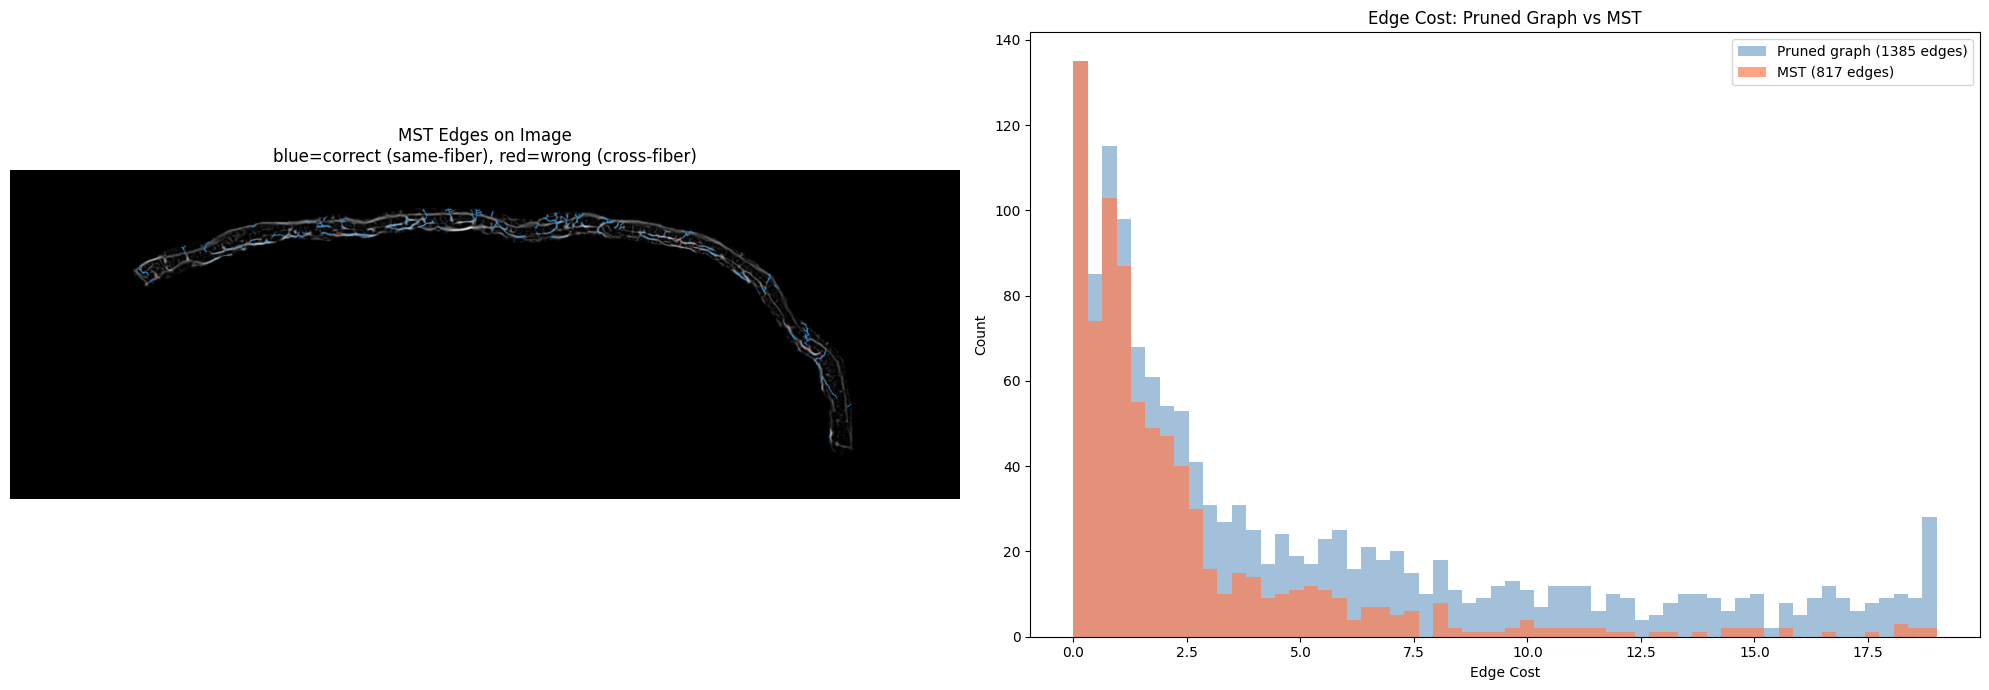

In [20]:
# ── Visualize MST edges on image ─────────────────────────────────────────
viz_mst = np.stack([roi_image] * 3, axis=-1).astype(np.uint8)

# Draw annotation component centroids
centroids = {}
for cid in range(1, n_components + 1):
    ys_c, xs_c = np.where(annot_labeled == cid)
    if len(ys_c) > 0:
        centroids[cid] = (int(ys_c.mean()), int(xs_c.mean()))

# Draw MST edges
for a, b, data in mst.edges(data=True):
    # Use the recorded meeting point as the edge midpoint
    my, mx = data['y'], data['x']
    gt_a = annot_to_gt.get(a, 0)
    gt_b = annot_to_gt.get(b, 0)
    if gt_a > 0 and gt_b > 0 and gt_a == gt_b:
        color = (30, 160, 255)   # blue = correct
    elif gt_a > 0 and gt_b > 0:
        color = (255, 50, 50)    # red = wrong
    else:
        color = (160, 160, 160)  # gray = unknown

    # Line from component A centroid to meeting point to component B centroid
    if a in centroids and b in centroids:
        cy_a, cx_a = centroids[a]
        cy_b, cx_b = centroids[b]
        cv2.line(viz_mst, (cx_a, cy_a), (mx, my), color, 1)
        cv2.line(viz_mst, (mx, my), (cx_b, cy_b), color, 1)
    cv2.circle(viz_mst, (mx, my), 3, color, -1)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

axes[0].imshow(viz_mst)
axes[0].set_title(f'MST Edges on Image\n'
                  f'blue=correct (same-fiber), red=wrong (cross-fiber)')
axes[0].axis('off')

# Edge cost distribution: pruned graph vs MST
if len(pruned_costs) > 0 and len(mst_costs) > 0:
    clip = np.percentile(np.concatenate([pruned_costs, mst_costs]), 99)
    axes[1].hist(np.clip(pruned_costs, 0, clip), bins=60, alpha=0.5,
                 label=f'Pruned graph ({len(pruned_costs)} edges)', color='steelblue')
    axes[1].hist(np.clip(mst_costs,    0, clip), bins=60, alpha=0.7,
                 label=f'MST ({len(mst_costs)} edges)', color='coral')
    axes[1].set_xlabel('Edge Cost')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Edge Cost: Pruned Graph vs MST')
    axes[1].legend()

# plt.suptitle(f'{IMAGE_ID}: Component MST  |  Precision={mst_precision*100:.1f}%  Recall={mst_recall*100:.1f}%',
#              fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
fig_size_x = 128
fig_size_y = int(roi_image.shape[0] / roi_image.shape[1] * fig_size_x)

fig, axes = plt.subplots(1, 1, figsize=(fig_size_x, fig_size_y))

axes.imshow(viz_mst)
axes.axis('off')

plt.tight_layout()
plt.savefig(f'viz_mst.png')
plt.close(fig)

## 9. Per-CC Skeletonization

For each MST connected component:
1. Build a mask = pixels owned by any component in the CC **AND** `dist_map < threshold`
2. Since annotation pixels have `dist=0`, they are always included
3. Skeletonize the mask → clean single-pixel centerline

The threshold controls how wide the corridor between components is before skeletonization.

In [22]:
import cv2
from skimage.morphology import skeletonize
from neural_reconstruction.core.topology import TopologyBuilder

topology_builder = TopologyBuilder(segment_length=100.0)
H, W = owner_map.shape

# ── 1. Draw backtracked inter-component paths as bridge mask ──────────────
bridge_mask = np.zeros((H, W), dtype=np.uint8)
for u, v, data in mst.edges(data=True):
    for (py, px) in data.get("path", []):
        if 0 <= py < H and 0 <= px < W:
            bridge_mask[py, px] = 1

# Dilate bridges by 3px radius (7x7 ellipse kernel)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
bridge_dilated = cv2.dilate(bridge_mask, kernel).astype(bool)

# ── 2. Merge with original annotation ────────────────────────────────────
combined = ((annotation_bin > 0) | bridge_dilated).astype(np.uint8)

# ── 3. Global skeletonization ─────────────────────────────────────────────
skeleton_all = skeletonize(combined)

# ── 4. Build pixel-level graph from combined mask ─────────────────────────
result_graph = topology_builder.build_seed_graph(combined)

print(f"Bridge path pixels (raw)  : {bridge_mask.sum():,}")
print(f"Bridge path pixels (dilated): {bridge_dilated.sum():,}")
print(f"Combined mask pixels      : {combined.sum():,}")
print(f"Skeleton pixels           : {skeleton_all.sum():,}")
print(f"Result graph              : {result_graph.number_of_nodes()} nodes, {result_graph.number_of_edges()} edges")

Bridge path pixels (raw)  : 3,797
Bridge path pixels (dilated): 39,984
Combined mask pixels      : 45,704
Skeleton pixels           : 7,815
Result graph              : 289 nodes, 253 edges


/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:125: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)


In [24]:
# ── Visualize skeletons ───────────────────────────────────────────────────
# Color each CC's skeleton by GT purity (pure=blue, merged=red, unknown=gray)

# skel_rgb = np.stack([roi_image] * 3, axis=-1).astype(np.uint8)

# for cc_id, cc_nodes in enumerate(nx.connected_components(mst)):
#     if cc_id not in cc_skeleton:
#         continue
#     skel = cc_skeleton[cc_id]

#     gt_ids_in_cc = {annot_to_gt.get(n, 0) for n in cc_nodes} - {0}
#     if len(gt_ids_in_cc) == 0:
#         color = np.array([160, 160, 160], dtype=np.uint8)  # gray = no GT
#     elif len(gt_ids_in_cc) == 1:
#         color = np.array([30, 160, 255], dtype=np.uint8)   # blue = pure
#     else:
#         color = np.array([255, 60, 60], dtype=np.uint8)    # red = merged

#     skel_rgb[skel] = color


fig_size_x = 128
fig_size_y = int(roi_image.shape[0] / roi_image.shape[1] * fig_size_x)

fig, axes = plt.subplots(1, 1, figsize=(fig_size_x, fig_size_y))

# axes[0].imshow(skel_rgb)
# axes[0].set_title(f'Skeletons (threshold={SKEL_DIST_THRESHOLD})\n'
#                   f'blue=pure CC, red=merged CC, gray=no GT')
# axes[0].axis('off')

# Overlay skeleton on image
overlay = np.stack([roi_image] * 3, axis=-1).astype(np.uint8)
overlay[combined > 0] = [200, 0, 200]  
# overlay[annotation_bin > 0] = [0, 200, 80]  # green = original annotation seeds
overlay[skeleton_all] = [255, 220, 0]  # yellow skeleton on gray image
axes.imshow(overlay)
axes.axis('off')
plt.tight_layout()
plt.savefig(f'skeletons_overlay.png')
plt.close(fig)

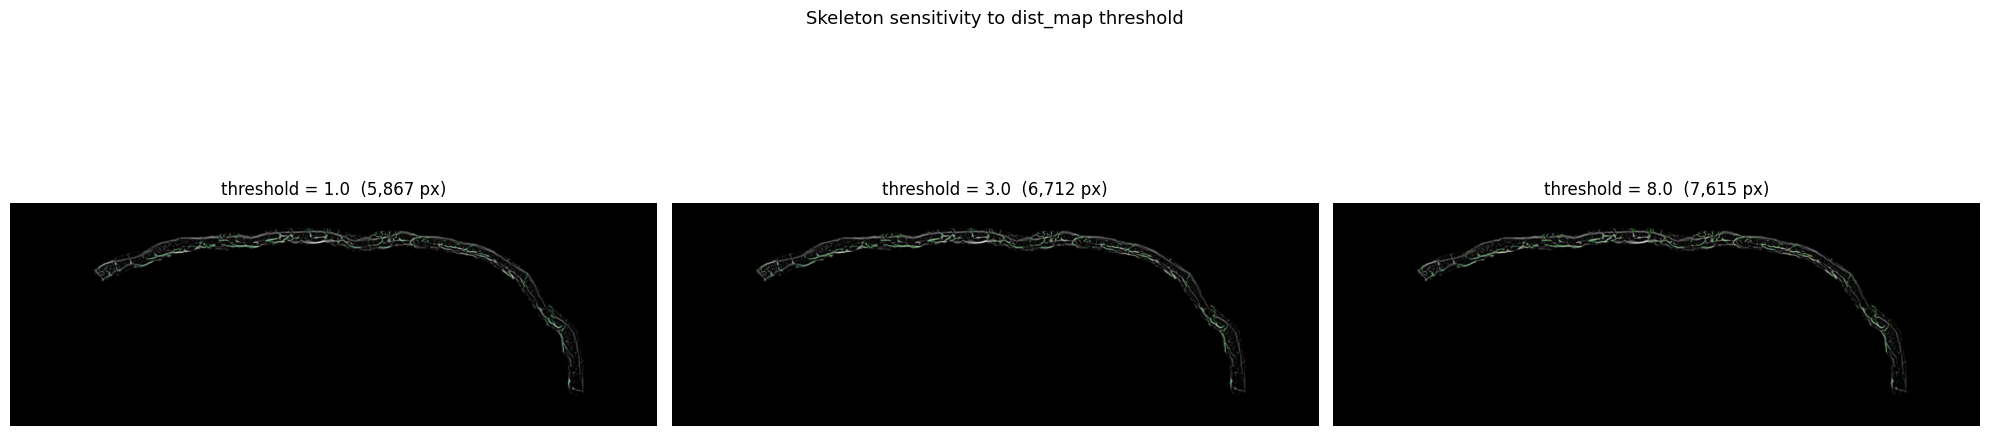

In [ ]:
# # ── Threshold sensitivity: compare 3 values side by side ─────────────────
# thresholds_to_try = [1.0, 3.0, 8.0]

# fig, axes = plt.subplots(1, len(thresholds_to_try), figsize=(20, 6))

# for ax, thr in zip(axes, thresholds_to_try):
#     skel_union = np.zeros((H, W), dtype=bool)
#     for cc_id, cc_nodes in enumerate(nx.connected_components(mst)):
#         owned    = np.isin(owner_map, list(cc_nodes))
#         corridor = owned & (dist_map < thr)
#         if corridor.sum() > 0:
#             skel_union |= skeletonize(corridor)

#     overlay = np.stack([roi_image] * 3, axis=-1).astype(np.uint8)
#     overlay[skel_union] = [255, 220, 0]
#     overlay[annotation_bin > 0] = [0, 200, 80]
#     ax.imshow(overlay)
#     ax.set_title(f'threshold = {thr}  ({skel_union.sum():,} px)')
#     ax.axis('off')

# plt.suptitle('Skeleton sensitivity to dist_map threshold', fontsize=13)
# plt.tight_layout()
# plt.show()

/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:125: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)


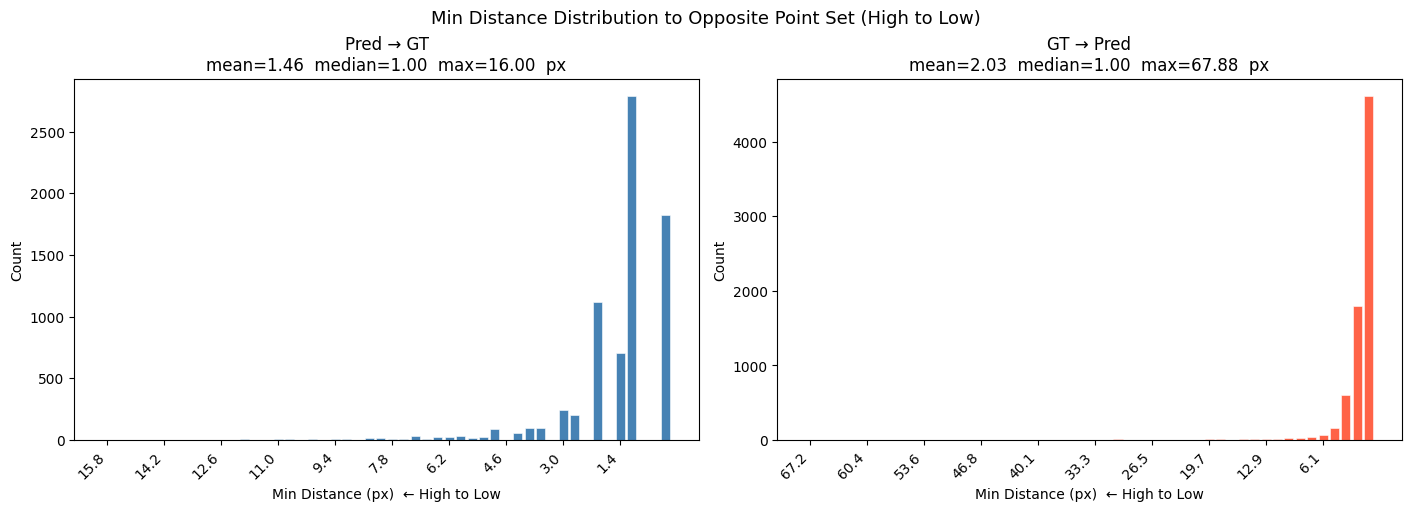

extend graph ClDice: 0.7048  TPrec: 0.8316  TSens: 0.6116


In [27]:

from neural_reconstruction.core.evaluation import (
    extract_graph_points,
    compute_average_hausdorff_distance,
    compute_point_min_distances,
    compute_cldice
)
extend_points = extract_graph_points(result_graph)
gt_graph = topology_builder.build_seed_graph(roi_label)
gt_points   = extract_graph_points(gt_graph)
min_pred_to_gt, min_gt_to_pred = compute_point_min_distances(extend_points, gt_points)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

BINS = 50

for ax, dists, label, color in [
    (axes[0], min_pred_to_gt, 'Pred → GT', 'steelblue'),
    (axes[1], min_gt_to_pred, 'GT → Pred', 'tomato'),
]:
    counts, edges = np.histogram(dists, bins=BINS)
    # Sort bins from high to low distance
    centers = (edges[:-1] + edges[1:]) / 2
    order   = np.argsort(centers)[::-1]
    ax.bar(range(BINS), counts[order], color=color, edgecolor='white', linewidth=0.4)
    ax.set_xticks(range(0, BINS, 5))
    ax.set_xticklabels([f'{centers[order][i]:.1f}' for i in range(0, BINS, 5)], rotation=45, ha='right')
    ax.set_xlabel('Min Distance (px)  ← High to Low')
    ax.set_ylabel('Count')
    ax.set_title(f'{label}\n'
                 f'mean={np.mean(dists):.2f}  median={np.median(dists):.2f}  '
                 f'max={np.max(dists):.2f}  px')

fig.suptitle('Min Distance Distribution to Opposite Point Set (High to Low)', fontsize=13)
plt.show()

cldice, tprec, tsens = compute_cldice(result_graph, roi_label, tolerance_px=1)
print(f"extend graph ClDice: {cldice:.4f}  TPrec: {tprec:.4f}  TSens: {tsens:.4f}")

## Conclusion

**Verdict:** Does the cost map quality look sufficient to guide fiber expansion in Step 3?

- Voronoi boundaries fall in dark areas → YES, cost map is working
- Boundaries cut through bright fibers → cost map needs adjustment (try different Sato sigmas, or cost function)